In [1]:
!pip install --pre mesa[viz]
!pip install numpy scipy matplotlib seaborn scikit-learn mesa==3.0 -q
# Requiero Mesa > 3.0.3
# Importamos las clases que se requieren para manejar los agentes (Agent) y su entorno (Model).
# Cada modelo puede contener múltiples agentes.
from mesa import Agent, Model

# Debido a que necesitamos que existe un solo agente por celda, elegimos ''SingleGrid''.
from mesa.space import MultiGrid

# Con ''RandomActivation'', hacemos que todos los agentes se activen de forma aleatoria.
from mesa.time import RandomActivation

from mesa.time import BaseScheduler

# Haremos uso de ''DataCollector'' para obtener información de cada paso de la simulación.
from mesa.datacollection import DataCollector

# Haremos uso de ''batch_run'' para ejecutar varias simulaciones
from mesa.batchrunner import batch_run

from heapq import heappush, heappop

# matplotlib lo usaremos crear una animación de cada uno de los pasos del modelo.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import numpy as np
plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Importamos los siguientes paquetes para el mejor manejo de valores numéricos.
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()

# Definimos otros paquetes que vamos a usar para medir el tiempo de ejecución de nuestro algoritmo.
import time
import datetime
import heapq

zsh:1: no matches found: mesa[viz]
zsh:1: command not found: pip
Could not import SolaraViz. If you need it, install with 'pip install --pre mesa[viz]'


/opt/homebrew/Cellar/jupyterlab/4.4.5/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#permite que el algoritmo a* explore primero los nudos con menor costo total estimado, mantiene una lista de los nodos
#ordenados segun prioridad
class PriorityQueue:
    def __init__(self):
        self.__data = []

    # Función para verificar si la fila de prioridades está vacía
    def empty(self):
        return not self.__data
    # Función para limpiar la fila de prioridades
    def clear(self):
        self.__data.clear()
    # Función para insertar un elemento en la fila de prioridades
    def push(self, priority, value):
        heapq.heappush(self.__data, (priority, value))
    # Función para extraer el elemento con mayor prioridad (menor número)
    def pop(self):
        if self.__data:
            return heapq.heappop(self.__data)
        else:
            raise Exception("No such element")
    # Función para obtener el primer elemento sin sacarlo
    def top(self):
        if self.__data:
            return self.__data[0]
        else:
            raise Exception("No such element")


In [3]:
class Rescatista(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.victims_rescued = 0
        self.cells_visited = 1
        self.moves = 4
        self.has_victim = False


    #uso static para pasar el model a a*, para asegurar que la ruta no cruce paredes
    # esta funcion fue sugerida por IA para una mejor implementacion de nuestro a*
    @staticmethod
    def can_move(modelo, current_pos, next_pos):
        x, y = current_pos
        nx, ny = next_pos
        dx, dy = nx - x, ny - y

        if dx == 1:
            direction = "E"
        elif dx == -1:
            direction = "W"
        elif dy == 1:
            direction = "N"
        elif dy == -1:
            direction = "S"
        else:
            return False
        obstacle = model.cells_obstacles[(x, y)][direction]
        if obstacle == 1:
            return False
        else:
            return True

    #vuelve a verificar las paredes y permite abrir puertas
    def allowed_move(self, current_pos, next_pos):
        x, y = current_pos
        nx, ny = next_pos
        dx, dy = nx - x, ny - y

        if dx == 1:
            direction = "E"
            opposite = "W"
        elif dx == -1:
            direction = "W"
            opposite = "E"
        elif dy == 1:
            direction = "N"
            opposite = "S"
        elif dy == -1:
            direction = "S"
            opposite = "N"
        else:
            return False

        # Verificar obstáculos
        if (x, y) in self.model.cells_obstacles:
            obstacle = self.model.cells_obstacles[(x, y)].get(direction, 0)
            if obstacle == 1:  # Pared
                return False
            elif obstacle == 2:  # Puerta cerrada
                print(f"Agente abre la puerta en {(x,y)} hacia {direction}. -1 movimiento")
                self.model.cells_obstacles[(x, y)][direction] = 0
                if (nx, ny) in self.model.cells_obstacles:
                    self.model.cells_obstacles[(nx, ny)][opposite] = 0
                self.moves -= 1
                self.model.count_moves += 1
                return True

        return True
    
    # el agente elimina zombie de la capa
    def elimina_zombie(self): 
        x, y = self.pos
        if self.model.cells_zombies[x][y] == 2 or 1:
            self.model.cells_zombies[x][y] = 0
    
    #busca la base mas cercana una vez que ya tiene la victima implementando a*
    def rescatar_persona(self):
      x, y = self.pos
      # Definir bases en los bordes
      bases = {(i, j) for i in range(len(self.model.cells))
                    for j in range(len(self.model.cells[0]))
                    if i in {0, len(self.model.cells)-1} or j in {0, len(self.model.cells[0])-1}}
      base = min(bases, key=lambda b: heuristics((x, y), b))

      # Crear una copia del grid para A* donde las celdas con fuego sean obstáculos
      temp_cells = [row[:] for row in self.model.cells]
      for i in range(len(temp_cells)):
          for j in range(len(temp_cells[0])):
              if self.model.cells_zombies[i][j] == 2:  # Fuego activo
                  temp_cells[i][j] = -1  # Marca como pared / obstáculo

      dist, path, _ = a_star(temp_cells, (x, y), base, self.model)

      if len(path) > 1:
          next_pos = path[1]
          if self.allowed_move((x, y), next_pos):
              old_pos = self.pos
              self.model.grid.move_agent(self, next_pos)
              self.cells_visited += 1
              print(f"Agente {self.unique_id}: Moviéndose de {old_pos} a {next_pos} hacia la base")

      if self.pos == base and self.has_victim:
          self.victims_rescued += 1
          self.model.count_victims_rescued += 1
          self.has_victim = False
          print(f"Agente {self.unique_id} llevó la víctima a la base {base}. Total rescatadas: {self.model.count_victims_rescued}")

    #define el step del agente (la logica con la que llevara a acabo las acciones)
    def step(self):
        print(f"\n--- Turno Agente {self.unique_id} en {self.pos} ---")
        print(f"Movimientos disponibles: {self.moves}")
        print(f"Víctimas rescatadas: {self.victims_rescued}")
        print(f"Cargando víctima: {'Sí' if self.has_victim else 'No'}")

        while self.moves >1:
            x, y = self.pos

            if not self.has_victim:
                cell_value = self.model.cells[x][y]
                #encuentra victima vdd
                if cell_value == 1:
                    self.model.cells[x][y] = 0
                    self.has_victim = True
                    print(f"Agente {self.unique_id}: Recogió una VÍCTIMA verdadera en {self.pos}. Movimientos restantes: {self.moves}")
                    self.model.new_victim()
                #encuentra victima falsa
                elif cell_value == 2:
                    self.model.cells[x][y] = 0
                    print(f"Agente {self.unique_id}: Falsa alarma en {self.pos}, se elimina. Movimientos restantes: {self.moves}")
                    self.model.new_victim()

                else:
                    # Buscar la víctima más cercana
                    victims = [(i, j) for i in range(len(self.model.cells))
                                       for j in range(len(self.model.cells[0]))
                                       if self.model.cells[i][j] in (1, 2)]
                    if victims:
                        victim = min(victims, key=lambda v: heuristics((x, y), v))
                        dist, path, _ = a_star(self.model.cells, (x, y), victim, self.model)
                        # No hay camino hacia víctima se mueve aleatorio
                        if not path or len(path) <= 1:
                            random_pos = (self.random.randrange(len(self.model.cells)),
                                          self.random.randrange(len(self.model.cells[0])))
                            dist, path, _ = a_star(self.model.cells, (x, y), random_pos, self.model)
                        if len(path) > 1:
                            next_pos = path[1]
                            if self.moves == 1 and self.model.cells_zombies[nx][ny] == 2:
                                print(f"Agente {self.unique_id}: Último movimiento, próxima celda ({nx},{ny}) tiene zombie despierto, se detiene")
                                return 
                            if self.model.cells_zombies[next_pos[0]][next_pos[1]] == 1:  
                                if self.allowed_move((x, y), next_pos):   
                                    old_pos = self.pos
                                    self.model.grid.move_agent(self, next_pos)
                                    self.cells_visited += 1
                                    self.elimina_zombie()
                                    self.moves -= 2
                                    self.model.count_moves += 2
                                    print(f"Agente {self.unique_id}: Se movió de {old_pos} a {next_pos} y eliminó un zombie dormido. Movimientos restantes: {self.moves}")
                            
                            elif self.model.cells_zombies[next_pos[0]][next_pos[1]] == 2: 
                                if self.allowed_move((x, y), next_pos):   
                                    old_pos = self.pos
                                    self.model.grid.move_agent(self, next_pos)
                                    self.cells_visited += 1
                                    self.elimina_zombie()
                                    self.moves -= 3
                                    self.model.count_moves += 3
                                    print(f"Agente {self.unique_id}: Se movió de {old_pos} a {next_pos} y eliminó un zombie despierto. Movimientos restantes: {self.moves}")

                            elif self.allowed_move((x, y), next_pos):
                                old_pos = self.pos
                                self.model.grid.move_agent(self, next_pos)
                                self.cells_visited += 1
                                self.moves -= 1
                                self.model.count_moves += 1
                                print(f"Agente {self.unique_id}: Moviéndose de {old_pos} a {next_pos}. Movimientos restantes: {self.moves}")
                            else:
                                self.moves -= 1
                        else:
                            self.moves -= 1
                    else:
                        self.moves -= 1
            else:
                old_pos = self.pos
                self.rescatar_persona()
                self.moves -= 2
                self.model.count_moves += 2
                if self.pos != old_pos:
                    print(f"Agente {self.unique_id}: Moviéndose de {old_pos} a {self.pos}. Movimientos restantes: {self.moves}")

        print(f"Agente {self.unique_id}: Turno completado. Recargando 4 movimientos.")
        self.moves += 4


In [4]:
INFINITE = 10**9
#define la heuristica
def heuristics(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
#convierte de las coordenadas que estamos usando a una matriz
def to_int(matrix, pos):
    rows, cols = len(matrix), len(matrix[0])
    return pos[0] * cols + pos[1]
#algoritmo a* que busca el camino mas corto hacia cierto objetivo
def a_star(matrix, src, dest, model):
    n = len(matrix) * len(matrix[0])
    dist = [INFINITE] * n
    prev = [None] * n
    pq = PriorityQueue()
    steps = 0

    dist[to_int(matrix, src)] = 0
    pq.push(0, src)
    while not pq.empty():
        current_dist, u = pq.top()
        pq.pop()

        if u == dest:
            break

        (x,y) = u
        neighbors = [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]

        for v in neighbors:
            (row, col) = v
            if 0 <= row < len(matrix) and 0 <= col < len(matrix[0]):
                if matrix[row][col] != -1 and Rescatista.can_move(model, (x,y), (row,col)):
                    new_dist = dist[to_int(matrix, u)] + 1
                    if new_dist < dist[to_int(matrix, v)]:
                        dist[to_int(matrix, v)] = new_dist
                        prev[to_int(matrix, v)] = u
                        priority = new_dist + heuristics(v, dest)
                        pq.push(priority, v)
        steps += 1

    # Reconstrucción del camino
    path = []
    u = dest
    if prev[to_int(matrix, u)] is not None or u == src:
        while u is not None:
            path.insert(0, u)
            u = prev[to_int(matrix, u)]

    return dist[to_int(matrix, dest)], path, steps

In [5]:
#grid para la simulacion visual
def get_grid(model):
    # Empezamos con la matriz base (víctimas, falsas alarmas, vacío)
    grid = np.zeros((model.grid.width, model.grid.height))

    for x in range(model.grid.width):
        for y in range(model.grid.height):
            grid[x][y] = model.cells[x][y]

    # Marcamos zombies
    for x in range(model.grid.width):
        for y in range(model.grid.height):
            if model.cells_zombies[x][y] == 1:  # Zombie dormido
                grid[x][y] = 3
            elif model.cells_zombies[x][y] == 2:  # Zombie despierto
                grid[x][y] = 5
            elif model.cells_zombies[x][y] == 3:  # Zombie atacando
                grid[x][y] = 6

    # Marcamos rescatistas
    for contents, (x, y) in model.grid.coord_iter():
        for agent in contents:
            if isinstance(agent, Rescatista):
                grid[x][y] = 4

    return grid



In [6]:
class RescatistaModel(Model):
    def __init__(self, width=10, height=8, agents=6, total_victims=15, initial_zombies=3):
        super().__init__()
        self.grid = MultiGrid(width, height, torus=False)
        self.schedule = RandomActivation(self)
        self.steps = 0
        self.count_moves = 0
        self.count_victims_rescued=0
        self.victims_killed = 0
        self.damaged_walls = 0
        self.max_steps = 50

        # recolecta datos
        self.datacollector = DataCollector(
            model_reporters={"Grid": get_grid,
                             "Steps": lambda model: model.steps,
                             "Clean": lambda model: 1 - (model.cells.sum() / model.cells.size)},
            agent_reporters={"Efficiency": lambda agent: agent.victims_rescued / agent.cells_visited,
                            "VictimsRescued": lambda agent: agent.victims_rescued})

        # Posicion inicial agentes
        forbidden_positions = {(x, y) for x in range(10) for y in range(8) if x in {0, 9} or y in {0, 7}}
        self.forbidden_positions = forbidden_positions
        base_positions = [(0, 5), (0, 4), (9, 3), (9, 4), (3, 0), (6, 7)]
        i = 0
        while i < agents and i < len(base_positions):
            pos = base_positions[i]
            if self.grid.is_cell_empty(pos):
                agent = Rescatista(self)
                self.grid.place_agent(agent, pos)
                self.schedule.add(agent)
                i += 1

        # Matriz que guarda víctimas y falsas alarmas
        self.cells = np.zeros((width, height))
        count = int((width * height * (total_victims / 100)))
        true_victims = 10
        false_alarms = 5
        while true_victims > 0:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.cells[x][y] == 0 and (x, y) not in forbidden_positions:
                self.cells[x][y] = 1
                true_victims -= 1
        while false_alarms > 0:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.cells[x][y] == 0 and (x, y) not in forbidden_positions:
                self.cells[x][y] = 2
                false_alarms -= 1

        # matriz de zombies
        self.cells_zombies = np.zeros((width, height))
        while initial_zombies > 0:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if self.cells_zombies[x][y] == 0 and (x, y) not in forbidden_positions:
                self.cells_zombies[x][y] = 1  # 1 = zombie
                initial_zombies -= 1

        self.cells_obstacles = {}
        for x in range(width):
            for y in range(height):
                self.cells_obstacles[(x,y)] = {"N": 0, "S": 0, "E": 0, "W": 0}
        # Paredes

        walls = {(1,1,"S"), (2,1,"S"), (4,1,"S"), (5,1,"S"), (6,1,"S"), (7,1,"S"), (8,1,"S"),
                (1,0,"N"), (2,0,"N"), (4,0,"N"), (5,0,"N"), (6,0,"N"), (7,0,"N"), (8,0,"N"),
                (1,6,"N"), (2,6,"N"), (3,6,"N"), (4,6,"N"), (5,6,"N"), (7,6,"N"), (8,1,"N"),
                (1,7,"S"), (2,7,"S"), (3,7,"S"), (4,7,"S"), (5,7,"S"), (7,7,"S"), (8,7,"S"),
                (1,1,"W"), (1,2,"W"), (1,3,"W"), (1,5,"W"), (1,6,"W"), (1,7,"W"),
                (0,1,"E"), (0,2,"E"), (0,3,"E"), (0,5,"E"), (0,6,"E"), (1,7,"E"),
                (9,1,"W"), (9,2,"W"), (9,4,"W"), (9,5,"W"), (9,6,"W"), (9,7,"W"),
                (8,1,"E"), (8,2,"E"), (8,4,"E"), (8,5,"E"), (8,6,"E"), (8,7,"E"),
                (3,5,"E"),(4,5,"W"),(5,6,"E"),(6,6,"W"),(2,3,"E"),(3,3,"W"),(6,4,"E"),(7,4,"W"),(5,2,"E"),(6,2,"W"),(7,2,"E"),(8,2,"W"),
                (3,2,"N"),(3,3,"S"),(2,2,"N"), (2,3,"S") ,(1,2,"N"),(1,3,"S"),(5,2,"N"),(5,3,"S"),(6,2,"N"),(6,3,"S"),(7,2,"N"),(7,3,"S"),
                (8,2,"N"),(8,3,"S"),(3,4,"N"),(3,5,"S"),(4,4,"N"),(4,5,"S"),(5,4,"N"),(5,5,"S"),(6,4,"N"),(6,5,"S"),(7,4,"N"),(7,5,"S")
                }
        for (x,y,side) in walls:
            self.cells_obstacles[(x,y)][side] = 1
        # Puertas
        doors = {(3,6,"E"),(4,6,"W"),(5,5,"E"),(6,5,"W"),(2,4,"E"),(3,4,"W"),(5,1,"E"),(6,1,"W"),(7,1,"E"),(8,1,"W"),(4,2,"N"),(4,3,"S"),(8,4,"N"),(8,5,"S"),
                (6,3,"E"), (7,3,"W")}
        for (x,y,side) in doors:
            self.cells_obstacles[(x,y)][side] = 2


    def step(self):
      self.steps += 1
      previous_counter = self.count_moves
      self.datacollector.collect(self)

      # Secuencial - cada agente se mueve
      for agent in self.schedule.agents:
          agent.step()
          self.new_zombie() 
          self.check_zombie_attacks()
      movements_this_step = self.count_moves - previous_counter

    # cuando los zombies se propagan en cadena, explosiones o ondas
    def check_zombie_attacks(self):
        width, height = self.grid.width, self.grid.height
        # Zombies atacantes se propagan 
        for x in range(width):
            for y in range(height):
                if self.cells_zombies[x][y] == 3:
                    if self.cells[x][y] > 0:
                        self.kill_victim(x, y)
                    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < width and 0 <= ny < height:
                            if self.cells[nx][ny] == -1:
                                self.cells[nx][ny] = -2
                                self.damaged_walls += 1
                                print(f"Zombie dañó pared en ({nx}, {ny})")
                                if self.cells[nx][ny] > 0:  
                                    self.kill_victim(nx, ny)
                                    print(f"¡Pared dañada en ({nx},{ny}) aplastó a la víctima en esa celda!")

                            elif (nx, ny) not in self.forbidden_positions:
                                if self.cells[nx][ny] > 0:
                                    self.kill_victim(nx, ny)
                                
                                # si a donde se propaga hay uno despierto se hace onda
                                if self.cells_zombies[nx][ny] == 2:
                                    print(f"¡Zombie en ({nx},{ny}) activó onda de fuego en dirección ({dx},{dy})!")
                                    
                                    # se exoande linealmente
                                    current_x, current_y = nx, ny
                                    while True:
                                        # Avanzar una celda más en la misma dirección
                                        current_x += dx
                                        current_y += dy
                                        
                                        # Verificar límites del grid
                                        if not (0 <= current_x < width and 0 <= current_y < height):
                                            break
                                        print(f"Onda de fuego alcanzó ({current_x}, {current_y})")
                                        # pared
                                        if self.cells[current_x][current_y] == -1:
                                            self.cells[current_x][current_y] = -2
                                            self.damaged_walls += 1
  
                                            print(f"¡Onda de fuego dañó pared en ({current_x}, {current_y})!")
                                            break  # La onda se detiene al dañar pared
                                        
                                        # encuentra puerta y la elimina
                                        elif self.cells[current_x][current_y] == -3:
                                            self.cells[current_x][current_y] = 0  # Eliminar puerta
                                            print(f"¡Onda de fuego destruyó puerta en ({current_x}, {current_y})!")
                                            break  # La onda se detiene al destruir puerta
                                        
                                        # fuera de los limites
                                        elif (current_x, current_y) in self.forbidden_positions:
                                            print(f"Onda de fuego se detuvo en posición prohibida ({current_x}, {current_y})")
                                            break

                                        else:
                                            # Si hay víctima o agente en la celda
                                            if self.cells[current_x][current_y] > 0:
                                                # Si es víctima, la mata
                                                self.kill_victim(current_x, current_y) 
                                                self.send_agent_to_base(x, y) 
                                                print(f"¡Onda de fuego mató a víctima en ({current_x}, {current_y})!")
                                                
                                                # Si es agente, lo manda a la base
                                                self.send_agent_to_base(current_x, current_y)
                                                print(f"¡Onda de fuego alcanzó a un agente en ({current_x}, {current_y}) y fue enviado a la base!")
                                        
                                            # Si está vacío, crear zombie tipo 2
                                            if self.cells_zombies[current_x][current_y] == 0:
                                                self.cells_zombies[current_x][current_y] = 2
                                                self.kill_victim(x, y)
                                                self.send_agent_to_base(x, y) 
                                                print(f"¡Onda de fuego creó zombie en ({current_x}, {current_y})!")
                                        
                                            # Si ya hay zombie, la onda continúa
                                            elif self.cells_zombies[current_x][current_y] in [1, 2]:
                                                print(f"Onda de fuego pasó por zombie en ({current_x}, {current_y})")
                                                continue  # La onda sigue propagándose
                                                                        
                                # Propagación normal (sin onda)
                                if self.cells_zombies[nx][ny] == 0:
                                    self.cells_zombies[nx][ny] = 2
                                    print(f"Zombie se expandió a ({nx}, {ny})")

    #crea y transforma los estados de los zombies
    def new_zombie(self):
        width, height = self.grid.width, self.grid.height
        attempts = 0
        max_attempts = 50
    
        while attempts < max_attempts:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
    
            if (x, y) not in self.forbidden_positions:
                # si esta vacia la celda aparece  dormido o despierto si hay uno cerca
                if self.cells_zombies[x][y] == 0:
                    hay_zombie_despierto_cerca = False
                    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < width and 0 <= ny < height:
                            if self.cells[nx][ny] >= 0 and self.cells_zombies[nx][ny] == 2:
                                hay_zombie_despierto_cerca = True
                                break  
                    if hay_zombie_despierto_cerca:
                        self.cells_zombies[x][y] = 2  
                        self.kill_victim(x, y)
                        self.send_agent_to_base(x, y)  
                        print(f"¡Zombie despierto apareció en ({x}, {y}) por proximidad!")
                    else:
                        self.cells_zombies[x][y] = 1  
                        print(f"¡Zombie dormido apareció en ({x}, {y})!")
                    return True
    
                # zombie dormido y despierta, adyacentes dormidos
                elif self.cells_zombies[x][y] == 1:
                    self.cells_zombies[x][y] = 2
                    self.kill_victim(x, y)
                    self.send_agent_to_base(x, y)
                    print(f"¡Zombie dormido en ({x}, {y}) despertó!")
    
                    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < width and 0 <= ny < height:
                            if self.cells[nx][ny] >= 0 and self.cells_zombies[nx][ny] == 1:
                                self.cells_zombies[nx][ny] = 2
                                self.kill_victim(x, y)
                                self.send_agent_to_base(x, y) 
                                print(f"¡Zombie dormido en ({nx}, {ny}) despertó por que el de al lado lo hizo!")
                    return True
    
                # zombie despierto se vuelve atacnte y se expande
                elif self.cells_zombies[x][y] == 2:
                    self.cells_zombies[x][y] = 3
                    self.kill_victim(x, y)
                    self.send_agent_to_base(x, y)
                    print(f"¡Zombie en ({x}, {y}) se volvió atacante!")
    
                    # Expandir a adyacentes
                    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < width and 0 <= ny < height:
                            if self.cells[nx][ny] >= 0:  # no pared/puerta
                                if self.cells_zombies[nx][ny] == 0:
                                    self.cells_zombies[nx][ny] = 2
                                    self.kill_victim(x, y)
                                    self.send_agent_to_base(x, y)
                                    print(f"¡Zombie despierto apareció en ({nx},{ny}) por ataque!")
                                elif self.cells_zombies[nx][ny] == 2:
                                    self.cells_zombies[nx][ny] = 3
                                    self.kill_victim(x, y)
                                    self.send_agent_to_base(x, y)
                                    print(f"¡Zombie en ({nx},{ny}) también se volvió atacante!")
                                if self.cells[nx][ny] > 0:
                                    self.kill_victim(nx, ny)
                                    self.send_agent_to_base(nx, ny)
                    return True
    
            attempts += 1
        return False

    #si hay fuego en la celda del agente lo manda a la ambulancia
    def send_agent_to_base(self, x, y):
        # Buscar agentes en esa celda
        cell_agents = self.grid.get_cell_list_contents((x, y))
        for agent in cell_agents:
            if isinstance(agent, Rescatista) or isinstance(agent, Survivor):  
                # Buscar base más cercana
                base_positions = [(0, 5), (0, 4), (9, 5), (9, 6), (3, 0), (4,0), (5,7), (6,7)]
                closest_base = min(base_positions, key=lambda b: abs(b[0]-x) + abs(b[1]-y))
                
                # Mover agente a esa base
                self.grid.move_agent(agent, closest_base)
                agent.has_victim = False  # si llevaba víctima, la pierde
                print(f"Agente {agent.unique_id} regreso a la base {closest_base} por ataque en ({x},{y})")

    #aparece nueva victima cada que una se muere 
    def new_victim(self):
        width, height = self.grid.width, self.grid.height
        attempts = 0
        max_attempts = 50
        while attempts < max_attempts:
            x = self.random.randrange(width)
            y = self.random.randrange(height)
            if (x, y) in self.forbidden_positions:
                attempts += 1
                continue
    
            # Si hay zombie en esa celda lo elimina y se pone ahi
            if self.cells_zombies[x][y] > 0:
                print(f"Zombie en ({x}, {y}) eliminado para que aparezca nueva víctima")
                self.cells_zombies[x][y] = 0
    
                victim_type = self.random.choice([1, 2])  
                self.cells[x][y] = victim_type
                print(f"Nueva {'víctima verdadera' if victim_type==1 else 'falsa alarma'} apareció en ({x}, {y})")
                return True
    
            # Si la celda está vacía, colocar víctima normal
            if self.cells[x][y] == 0:
                victim_type = self.random.choice([1, 2])
                self.cells[x][y] = victim_type
                print(f"Nueva {'víctima verdadera' if victim_type==1 else 'falsa alarma'} apareció en ({x}, {y})")
                return True
    
            attempts += 1
    
        return False
    
    #se muere la victima
    def kill_victim(self, x, y):
        if self.cells[x][y] > 0:
            print(f"¡Víctima en ({x}, {y}) ha muerto por el zombie!")
            self.cells[x][y] = 0
            self.victims_killed += 1
            
    # el juego acaba bajo cierta condiciones
    def end_game(self):
        # Fin si se rescataron 7 víctimas
        if self.count_victims_rescued >= 7:
            print(f"¡Se rescataron {self.count_victims_rescued} víctimas! Fin del juego.")
            return True
    
        # Fin si se alcanzó límite de víctimas muertas
        if self.victims_killed >= 4:
            print(f"¡Se alcanzó el límite de víctimas muertas ({self.victims_killed})! Fin del juego.")
            return True

        if self.damaged_walls >= 24:
            print("¡Se alcanzó el máximo de paredes danadas! Fin del juego.")
            return True

        if self.steps >= self.max_steps:
            print("¡Se alcanzó el máximo de turnos! Fin del juego.")
            return True

        return False
    
    def is_win(self):
        return self.count_victims_rescued >= 7



In [7]:
N_RUNS = 100

# Acumuladores
total_turns = 0
total_rescued = 0
total_killed = 0
total_damaged_walls = 0
wins = 0
losses = 0

start_time = time.time()

for i in range(N_RUNS):
    model = RescatistaModel()
    while not(model.end_game()):
        model.step()
    
    turns = model.steps / 2  
    total_turns += turns
    total_rescued += model.count_victims_rescued
    total_killed += model.victims_killed
    total_damaged_walls += model.damaged_walls

    if model.is_win():   
        wins += 1
        result = "GANADA"
    else:
        losses += 1
        result = "PERDIDA"

    print(f" Run {i+1}: {result} | Turnos={turns}, Rescatadas={model.count_victims_rescued}, "
          f"Muertas={model.victims_killed}, Paredes dañadas={model.damaged_walls}")

# Promedios
avg_turns = total_turns / N_RUNS
avg_rescued = total_rescued / N_RUNS
avg_killed = total_killed / N_RUNS
avg_damaged_walls = total_damaged_walls / N_RUNS
avg_wins = wins / N_RUNS
avg_losses = losses / N_RUNS

print("\n Promedios")
print(f"Promedio de turnos: {avg_turns}")
print(f"Promedio de víctimas rescatadas: {avg_rescued}")
print(f"Promedio de víctimas muertas: {avg_killed}")
print(f"Promedio de paredes dañadas: {avg_damaged_walls}")
print(f"Promedio de partidas GANADAS: {avg_wins}")
print(f"Promedio de partidas PERDIDAS: {avg_losses}")

print('\n Tiempo total de ejecución:', str(datetime.timedelta(seconds=(time.time() - start_time))))


/var/folders/dn/5ql9xhh142x5ghy3nv73jhp00000gn/T/ipykernel_339/1175702208.py:5: DeprecationWarning: The time module and all its Schedulers are deprecated and will be removed in a future version. They can be replaced with AgentSet functionality. See the migration guide for details. https://mesa.readthedocs.io/latest/migration_guide.html#time-and-schedulers
  self.schedule = RandomActivation(self)



--- Turno Agente 1 en (0, 5) ---
Movimientos disponibles: 4
Víctimas rescatadas: 0
Cargando víctima: No
Agente 1: Moviéndose de (0, 5) a (0, 4). Movimientos restantes: 3
Agente 1: Moviéndose de (0, 4) a (1, 4). Movimientos restantes: 2
Agente 1: Recogió una VÍCTIMA verdadera en (1, 4). Movimientos restantes: 2
Nueva falsa alarma apareció en (3, 5)
Agente 1: Moviéndose de (1, 4) a (0, 4) hacia la base
Agente 1 llevó la víctima a la base (0, 4). Total rescatadas: 1
Agente 1: Moviéndose de (1, 4) a (0, 4). Movimientos restantes: 0
Agente 1: Turno completado. Recargando 4 movimientos.
¡Zombie dormido apareció en (4, 6)!

--- Turno Agente 2 en (0, 4) ---
Movimientos disponibles: 4
Víctimas rescatadas: 0
Cargando víctima: No
Agente 2: Moviéndose de (0, 4) a (1, 4). Movimientos restantes: 3
Agente 2: Moviéndose de (1, 4) a (2, 4). Movimientos restantes: 2
Agente 2: Recogió una VÍCTIMA verdadera en (2, 4). Movimientos restantes: 2
Nueva falsa alarma apareció en (4, 2)
Agente 2: Moviéndose de 

In [30]:
all_agents_info = model.datacollector.get_agent_vars_dataframe()
all_agents_info.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 24 entries, (np.int64(2), np.int64(1)) to (np.int64(8), np.int64(6))
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Efficiency      24 non-null     float64
 1   VictimsRescued  24 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 949.0 bytes


In [9]:
# Obtenemos la información que almacenó el colector, este nos entregará un DataFrame de pandas que contiene toda la información.
all_grids = model.datacollector.get_model_vars_dataframe()
all_grids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Grid    5 non-null      object 
 1   Steps   5 non-null      int64  
 2   Clean   5 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 252.0+ bytes


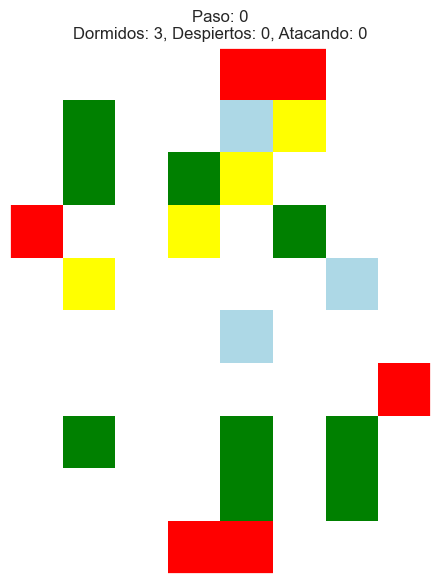

In [10]:
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_xticks([])
axs.set_yticks([])

cmap = plt.cm.colors.ListedColormap([
    'white',       # 0 vacío
    'green',       # 1 víctima
    'yellow',      # 2 falsa alarma
    'lightblue',   # 3 zombie dormido
    'red',         # 4 agente
    'orange',      # 5 zombie despierto
    'darkred'      # 6 zombie atacando
])
bounds = [0, 1, 2, 3, 4, 5, 6, 7]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

patch = plt.imshow(all_grids.iloc[0, 0], cmap=cmap, norm=norm)

def animate(i):
    if i < len(all_grids):
        patch.set_data(all_grids.iloc[i, 0])
        current_grid = all_grids.iloc[i, 0]
        zombies_dormidos = np.sum(current_grid == 3)
        zombies_despiertos = np.sum(current_grid == 5)
        zombies_atacando = np.sum(current_grid == 6)
        axs.set_title(f'Paso: {i}\nDormidos: {zombies_dormidos}, Despiertos: {zombies_despiertos}, Atacando: {zombies_atacando}')
    return patch,

# Definir el número de frames
num_frames = len(all_grids)

anim = animation.FuncAnimation(fig, animate, frames=num_frames, interval=500, blit=True)

plt.tight_layout()
plt.show()
# Mo

In [99]:
anim